In [1]:
import subprocess
import matplotlib.pyplot as plt
import json, yaml
import os, sys
from pathlib import Path
import numpy as np
import pandas as pd
from IPython.display import Image, display

def find_repo_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "PROJECT_EXPERIMENT_GUIDE.md").exists() and (candidate / "README.md").exists():
            return candidate
    raise RuntimeError("Could not find the XLZD repo root from the current working directory.")

REPO_ROOT = find_repo_root()
os.chdir(REPO_ROOT)
CNP_MFGP_ROOT = REPO_ROOT / "cnp_mfgp"
if str(CNP_MFGP_ROOT) not in sys.path:
    sys.path.insert(0, str(CNP_MFGP_ROOT))
from cnp_mfgp.visualize import plot_cnp_pred_shell_occupancy


VAL_DATA = REPO_ROOT / "data" / "val_data"
VAL_OUTPUT = CNP_MFGP_ROOT / "outputs" / "validation"
CNP_MODEL = list((CNP_MFGP_ROOT / "outputs" / "train" / "cnp").glob("*.pth"))[0]
MFGP_MODEL = list((CNP_MFGP_ROOT / "outputs" / "train" / "mfgp").glob("*.joblib"))[0]

## Run the Validation

In [2]:
cmd = [
    sys.executable,
    "cnp_mfgp/validate_cnp_mfgp.py",
    "--raw-dir",
    str(VAL_DATA),
    "--cnp-model",
    str(CNP_MODEL),
    "--mfgp-model",
    str(MFGP_MODEL),
    "--output-dir",
    str(VAL_OUTPUT),
]

print("$ " + " ".join(cmd))
subprocess.run(cmd, cwd=REPO_ROOT, check=True)

$ /home/pknauss/xlzd/bin/python cnp_mfgp/validate_cnp_mfgp.py --raw-dir /home/pknauss/XLZD/data/val_data --cnp-model /home/pknauss/XLZD/cnp_mfgp/outputs/train/cnp/cnp_xlzd_shell_minibatch_model_15epochs.pth --mfgp-model /home/pknauss/XLZD/cnp_mfgp/outputs/train/mfgp/mfgp_xlzd_shell_minibatch_linear_model_iter0.joblib --output-dir /home/pknauss/XLZD/cnp_mfgp/outputs/validation


/home/pknauss/xlzd/lib/python3.14/site-packages/torch/cuda/__init__.py:188: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 12090). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /__w/pytorch/pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._cuda_getDeviceCount() > 0



STRICT CNP -> MF-GP HOLDOUT VALIDATION
Validation data:   /home/pknauss/XLZD/data/val_data
Manifest:          /home/pknauss/XLZD/data/val_data/validation_manifest.csv
CNP checkpoint:    /home/pknauss/XLZD/cnp_mfgp/outputs/train/cnp/cnp_xlzd_shell_minibatch_model_15epochs.pth
CNP context:       embedded in checkpoint
MF-GP checkpoint:  /home/pknauss/XLZD/cnp_mfgp/outputs/train/mfgp/mfgp_xlzd_shell_minibatch_linear_model_iter0.joblib
Output directory:  /home/pknauss/XLZD/cnp_mfgp/outputs/validation
Embedded context:  4,096 events
[prepare] R1712_H825_F1_2447keVgamma_withcuts.csv | R=1712, Z=825, z_center=825, fidelity=1
[prepare] R857_H1767_F1_2447keVgamma_withcuts.csv | R=857, Z=1767, z_center=1767, fidelity=1
[prepare] R1246_H1381_F1_2447keVgamma_withcuts.csv | R=1246, Z=1381, z_center=1381, fidelity=1
[prepare] R400_H200_F1_2447keVgamma_withcuts.csv | R=400, Z=200, z_center=200, fidelity=1
[prepare] R1187_H733_F1_2447keVgamma_withcuts.csv | R=1187, Z=733, z_center=733, fidelity=1
[pr

CNP holdout validation: 100%|██████████| 12/12 [02:43<00:00, 13.64s/file]


[CNP] predictions -> /home/pknauss/XLZD/cnp_mfgp/outputs/validation/cnp/cnp_holdout_shell_distributions.csv
[CNP] geometry metrics -> /home/pknauss/XLZD/cnp_mfgp/outputs/validation/cnp/cnp_holdout_geometry_metrics.csv
[CNP] overall metrics -> /home/pknauss/XLZD/cnp_mfgp/outputs/validation/cnp/cnp_holdout_overall_metrics.json
[MF-GP] loaded checkpoint -> /home/pknauss/XLZD/cnp_mfgp/outputs/train/mfgp/mfgp_xlzd_shell_minibatch_linear_model_iter0.joblib
[MF-GP] metrics -> /home/pknauss/XLZD/cnp_mfgp/outputs/validation/mfgp/mfgp_xlzd_shell_minibatch_linear_savedmodel_validation_metrics_iter0.json
[MF-GP] validation predictions -> /home/pknauss/XLZD/cnp_mfgp/outputs/validation/mfgp/mfgp_xlzd_shell_minibatch_linear_savedmodel_validation_predictions_iter0.csv
[MF-GP] prediction grid -> /home/pknauss/XLZD/cnp_mfgp/outputs/validation/mfgp/mfgp_xlzd_shell_minibatch_linear_savedmodel_grid_iter0.csv
[MF-GP] three standard plots -> /home/pknauss/XLZD/cnp_mfgp/outputs/validation/mfgp/mfgp_xlzd_shell

CompletedProcess(args=['/home/pknauss/xlzd/bin/python', 'cnp_mfgp/validate_cnp_mfgp.py', '--raw-dir', '/home/pknauss/XLZD/data/val_data', '--cnp-model', '/home/pknauss/XLZD/cnp_mfgp/outputs/train/cnp/cnp_xlzd_shell_minibatch_model_15epochs.pth', '--mfgp-model', '/home/pknauss/XLZD/cnp_mfgp/outputs/train/mfgp/mfgp_xlzd_shell_minibatch_linear_model_iter0.joblib', '--output-dir', '/home/pknauss/XLZD/cnp_mfgp/outputs/validation'], returncode=0)

## CNP Metrics

In [ ]:
# Grab finalized report and files
with open(VAL_OUTPUT / "holdout_validation_report.json", "r") as f:
    report = json.load(f)
artifacts = report["artifacts"]

# Print CNP metrics
cnp_wanted = {
    "top1_accuracy": "Top-1 Accuracy",
    "mean_abs_shell_error": "Mean Shell Error",
    "mean_true_shell_probability": "True-Shell Probability",
    "mean_geometry_js_divergence": "JS Divergence",
}
cnp_metrics = pd.DataFrame(
    [[label, report["cnp_holdout"][key]] for key, label in cnp_wanted.items()], 
    columns=["Metric", "Value"],)

print("=" * 15 + " CNP Validation " + "=" * 15)
display(cnp_metrics.style.hide(axis="index").format({"Value": "{:.4g}"}))

# Plot CNP shell distribution
cnp_csv = Path(artifacts["cnp_shell_distribution_csv"])
fig, axes = plot_cnp_pred_shell_occupancy(cnp_csv)
plt.show()

## MFGP Metrics

In [ ]:
# MFGP 

In [3]:
# Display useful validation metrics
with open(VAL_OUTPUT / "holdout_validation_report.json", "r") as f:
    report = json.load(f)
artifacts = report["artifacts"]

# ============================================================
# CNP Metrics
# ============================================================
cnp_wanted = {
    "top1_accuracy": "Top-1 Accuracy",
    "mean_abs_shell_error": "Mean Shell Error",
    "mean_true_shell_probability": "True-Shell Probability",
    "mean_geometry_js_divergence": "JS Divergence",
}
cnp_metrics = pd.DataFrame(
    [[label, report["cnp_holdout"][key]] for key, label in cnp_wanted.items()], 
    columns=["Metric", "Value"],)

print("=" * 15 + " CNP Validation " + "=" * 15)
display(cnp_metrics.style.hide(axis="index").format({"Value": "{:.4g}"}))

# ============================================================
# MF-GP Metrics
# ============================================================
artifacts = report["artifacts"]
with open(artifacts["mfgp_metrics_json"], "r") as f:
    mfgp = json.load(f)

mfgp_metrics = pd.DataFrame(
    [["MAE", mfgp["mae"]],
    ["RMSE", mfgp["rmse"]],
    ["R²", mfgp["r2"]],
    ["Mean Residual", mfgp["mean_residual"]],
    ["1σ Coverage", f"{100*mfgp['coverage_1sigma']:.1f}%"]],
    columns=["Metric", "Value"])

print("=" * 15 + " MFGP Validation " + "=" * 15)
display(mfgp_metrics.style.hide(axis="index"))

=============== CNP Validation ===============


Metric,Value
Top-1 Accuracy,0.06804
Mean Shell Error,15.59
True-Shell Probability,0.03388
JS Divergence,0.001252


=============== MFGP Validation ===============


Metric,Value
MAE,0.001317
RMSE,0.002216
R²,0.989897
Mean Residual,0.000860
1σ Coverage,83.3%


Predicted minus truth total:    0.22


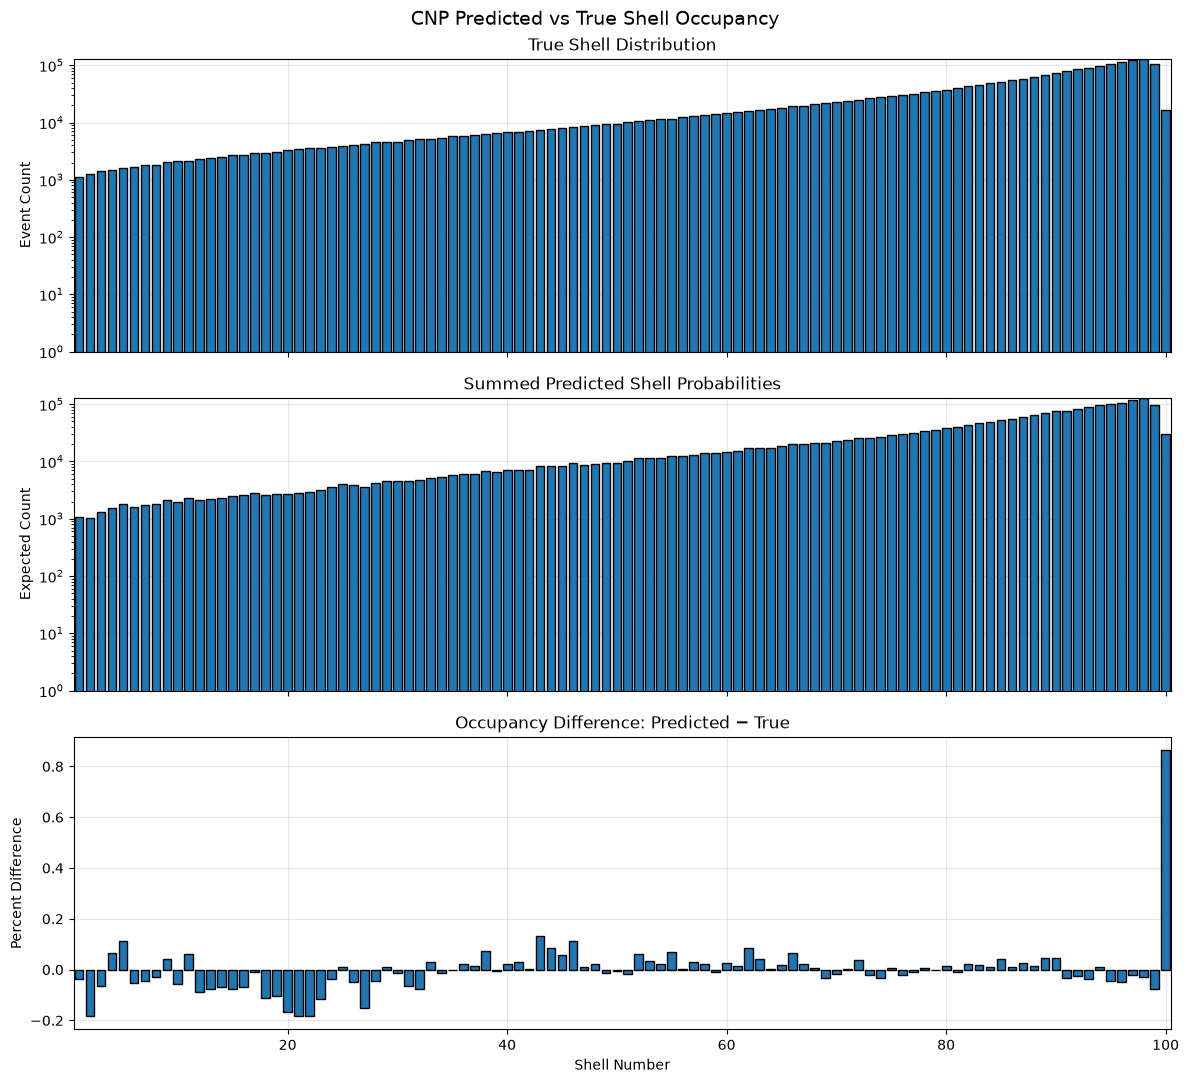

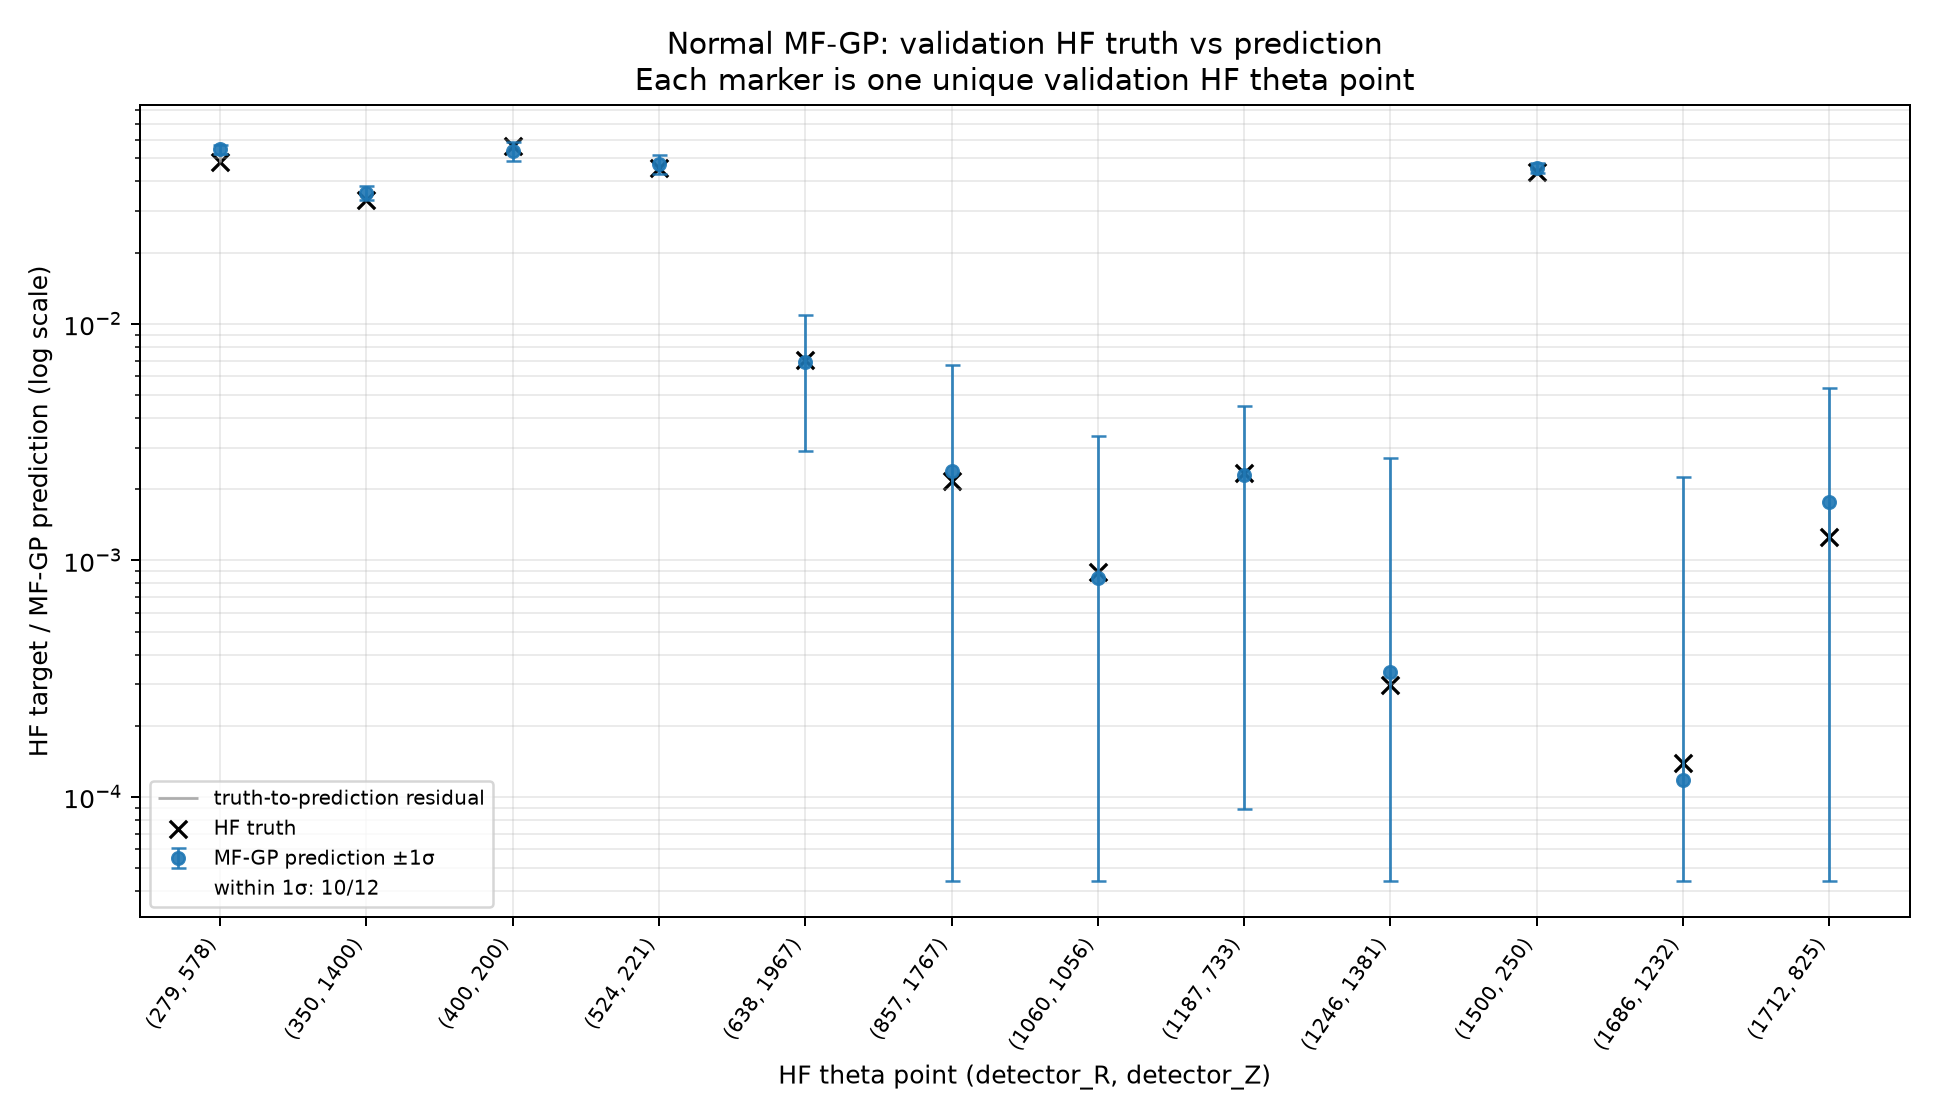

In [5]:
# ============================================================
# CNP Predicted Shell Occupancy
# ============================================================
cnp_csv = Path(artifacts["cnp_shell_distribution_csv"])
fig, axes = plot_cnp_pred_shell_occupancy(cnp_csv)
plt.show()

# ============================================================
# MF-GP Validation Point Plot
# ============================================================
mfgp_plot = Path(artifacts["mfgp_validation_point_plot"])
if mfgp_plot.exists():
    display(Image(filename=str(mfgp_plot)))